# Proyecto Machine Learning - Máster Data Science & IA


*Víctor Horcas Puertas*

## 1. Carga de datos

Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Estilo global de gráficos
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

Carga de los 2 datasets en formato csv

In [ ]:
data = Path('datasets')

file_1 = data / 'online_retail_II.xlsx - Year 2009-2010.csv'
file_2 = data / 'online_retail_II.xlsx - Year 2010-2011.csv'

# Cargo los dos archivos y los uno
df1 = pd.read_csv(file_1, parse_dates=['InvoiceDate'])
df2 = pd.read_csv(file_2, parse_dates=['InvoiceDate'])
df_raw = pd.concat([df1, df2], ignore_index=True)

In [4]:
print(f'Dataset raw → {len(df_raw):,} filas | {df_raw.shape[1]} columnas')

Dataset raw → 1,067,371 filas | 8 columnas


Primera inspección

In [4]:
df_raw.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 65.1 MB


In [10]:
df_raw.dtypes

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

## 2. Calidad y limpieza de los datos (Análisis EDA)

Limpieza inicial:
- Elimino las facturas que empiezan por `C`, ya que, son **cancelaciones**, no ventas reales.
- Elimino las filas sin `Customer ID`.
- Elimino `Quantity <= 0`, valores negativos o cero no tienen sentido como venta (valores atípicos).
- Elimino `Price <= 0`, artículos gratuitos o con precio inválido distorsionan el análisis.

In [6]:
cancel = df_raw['Invoice'].astype(str).str.startswith('C')   # cancelaciones
no_id  = df_raw['Customer ID'].isna()                         # sin Customer ID
qty    = df_raw['Quantity'] <= 0                              # cantidad inválida
price  = df_raw['Price'] <= 0                                 # precio inválido

# Impacto de cada filtro
print('=== Filas eliminadas por cada filtro ===')
print(f'  Cancelaciones (Invoice "C..."): {cancel.sum():>7,}')
print(f'  Sin Customer ID:               {no_id.sum():>7,}')
print(f'  Quantity <= 0:                 {qty.sum():>7,}')
print(f'  Price <= 0:                    {price.sum():>7,}')

# Aplico todos los filtros
df = df_raw[~cancel & ~no_id & ~qty & ~price].copy()

# Creamos la columna Revenue = Quantity × Price (ingreso por línea de factura)
df['Revenue'] = df['Quantity'] * df['Price']

print(f'\nFilas antes de limpiar: {len(df_raw):>10,}')
print(f'Filas después de limpiar: {len(df):>8,}')
print(f'Clientes únicos: {df["Customer ID"].nunique():>13,}')
print(f'Rango fechas: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')

=== Filas eliminadas por cada filtro ===
  Cancelaciones (Invoice "C..."):  19,494
  Sin Customer ID:               243,007
  Quantity <= 0:                  22,950
  Price <= 0:                      6,207

Filas antes de limpiar:  1,067,371
Filas después de limpiar:  805,549
Clientes únicos:         5,878
Rango fechas: 2009-12-01 → 2011-12-09


**Valores nulos**

In [6]:
# Nulos residuales tras la limpieza
nulos = df.isnull().sum()
nulos_percentage = (nulos / len(df) * 100).round(2)
print(pd.DataFrame({'nulos': nulos, '%': nulos_percentage}).query('nulos > 0'))
# Description puede tener algunos nulos residuales — no es una feature del modelo, no es problema

Empty DataFrame
Columns: [nulos, %]
Index: []


**Valores duplicados**

In [7]:
# Duplicados exactos
n_dup = df.duplicated().sum()
print(f'Filas duplicadas exactas: {n_dup:,}')

Filas duplicadas exactas: 26,124


In [8]:
# Elimino los duplicados exactos
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'Valores restantes: {len(df):,}')

Valores restantes: 779,425


## 3. Estadísticas descriptivas y visualizaciones

In [9]:
df[['Quantity', 'Price', 'Revenue']].describe()

,Quantity,Price,Revenue
count,779425.00,779425.00,779425.00
mean,13.49,3.22,22.29
std,145.86,29.68,227.43
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,12.48
75%,12.00,3.75,19.80
max,80995.00,10953.50,168469.60


**Valores atípicos (outliers)**

1. **Identifico** los casos extremos con boxplots y tabla de top transacciones
2. **Elimino** filas donde `Quantity > p = 0.999` **o** `Price > p = 0.999`, ya que, representan errores o casos irrepresentables
3. **Los mayoristas normales** (por encima de la media pero bajo el umbral) se conservan y se gestionan con `RobustScaler`

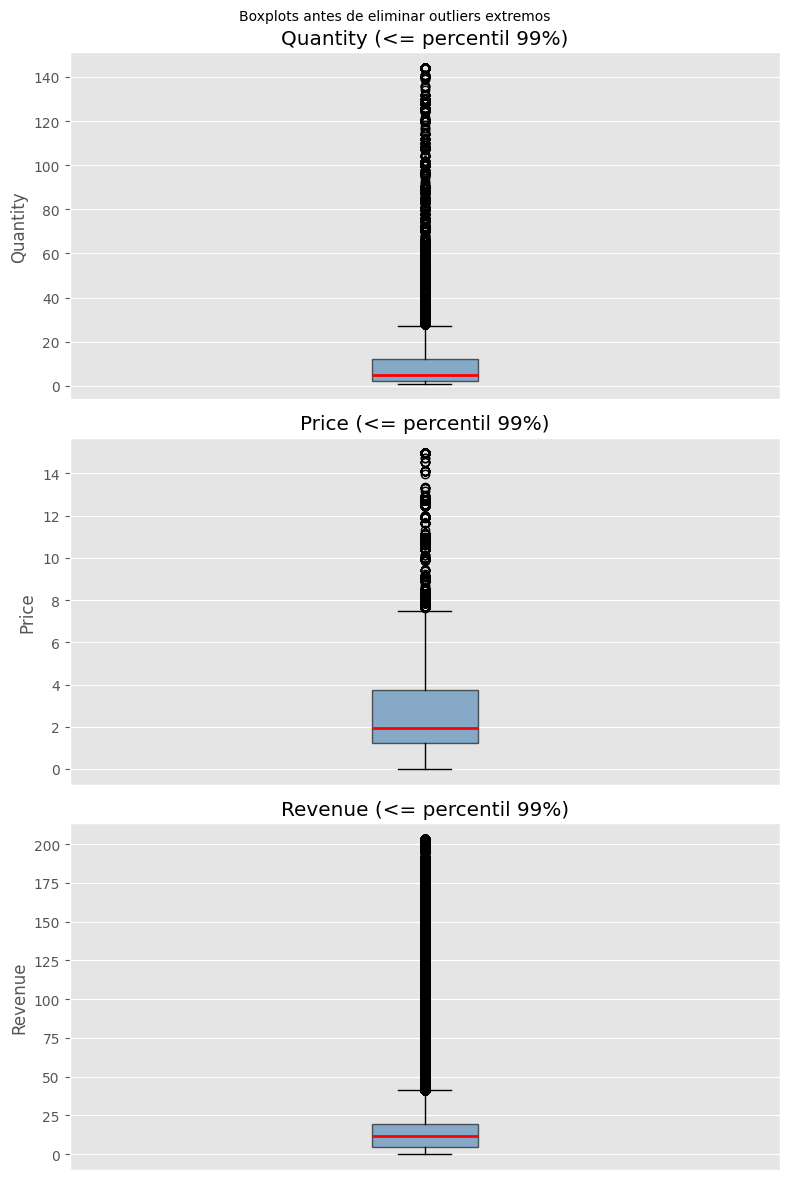

In [9]:
''' 
    Boxplots para visualizar la distribución antes de eliminar los valores atípicos 
    (recortados al percentil 99% para visualizar)
'''
fig, axes = plt.subplots(3, 1, figsize=(8, 12))
cols   = ['Quantity', 'Price', 'Revenue']
titles = ['Quantity', 'Price', 'Revenue']

for ax, col, title in zip(axes, cols, titles):
    p99  = df[col].quantile(0.99)
    data = df.loc[df[col] <= p99, col]
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{title} (<= percentil 99%)')
    ax.set_ylabel(col)
    ax.set_xticks([])

plt.suptitle('Boxplots antes de eliminar outliers extremos', fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
# Calculamos umbrales en el percentil 99.9% para capturar solo los casos verdaderamente atípicos
outliers_qty   = df['Quantity'].quantile(0.999)
outliers_price = df['Price'].quantile(0.999)

print(f'Umbral Quantity (p99.9): {outliers_qty:.0f} unidades')
print(f'Umbral Price    (p99.9): {outliers_price:.2f} libras')

Umbral Quantity (p99.9): 576 unidades
Umbral Price    (p99.9): 49.95 libras


In [11]:
clean_outliers = (df['Quantity'] > outliers_qty) | (df['Price'] > outliers_price)

print(f'Filas eliminadas: {clean_outliers.sum():,} ({clean_outliers.mean()*100:.2f}% del dataset)')
print(f'Clientes afectados: {df[clean_outliers]["Customer ID"].nunique()}')

# Aplico el filtro
df = df[~clean_outliers].copy()

print(f'Filas tras eliminar outliers: {len(df):,}')
print(f'Clientes unicos finales: {df["Customer ID"].nunique():,}')

Filas eliminadas: 1,513 (0.19% del dataset)
Clientes afectados: 443
Filas tras eliminar outliers: 777,912
Clientes unicos finales: 5,840


**Estadísticas descriptivas, tras la limpieza de outliers**

In [13]:
df[['Quantity', 'Price', 'Revenue']].describe()

,Quantity,Price,Revenue
count,777912.00,777912.00,777912.00
mean,11.90,2.93,20.79
std,27.83,3.11,53.53
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,12.48
75%,12.00,3.75,19.80
max,576.00,49.95,4401.00


**Distribuciones**

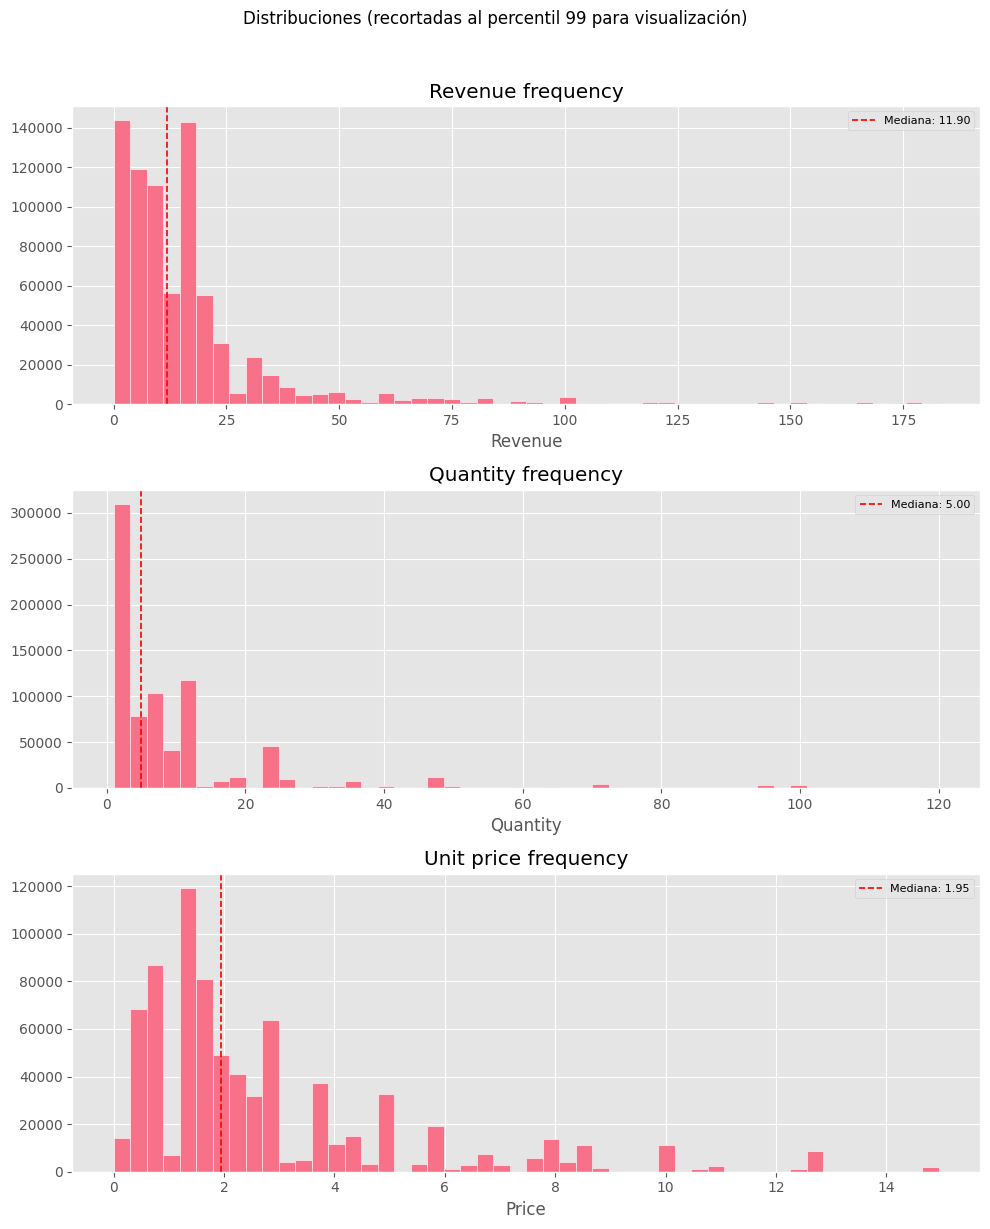

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
cols = ['Revenue', 'Quantity', 'Price']
titles = ['Revenue frequency', 'Quantity frequency', 'Unit price frequency']

for ax, col, title in zip(axes, cols, titles):
    p99 = df[col].quantile(0.99)          # recortamos al percentil 99
    data = df.loc[df[col] <= p99, col]
    ax.hist(data, bins=50, edgecolor='white', linewidth=0.4)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2, label=f'Mediana: {data.median():.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones (recortadas al percentil 99 para visualización)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Serie temporal de ventas**

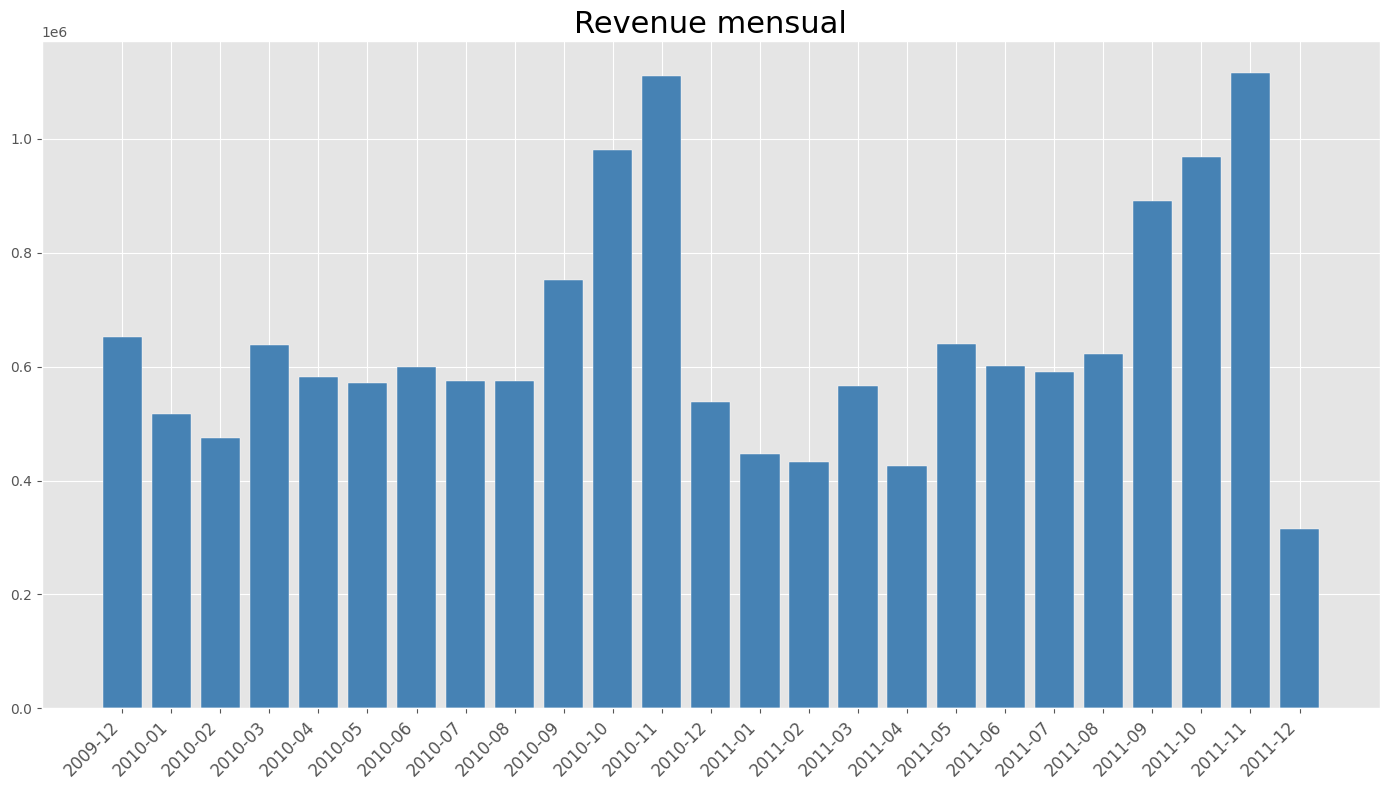

In [20]:
# Agrupamos por mes (período)
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(monthly['YearMonth_str'], monthly['Revenue'], color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title('Revenue mensual', fontsize=22)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

**Top 10 países y productos**

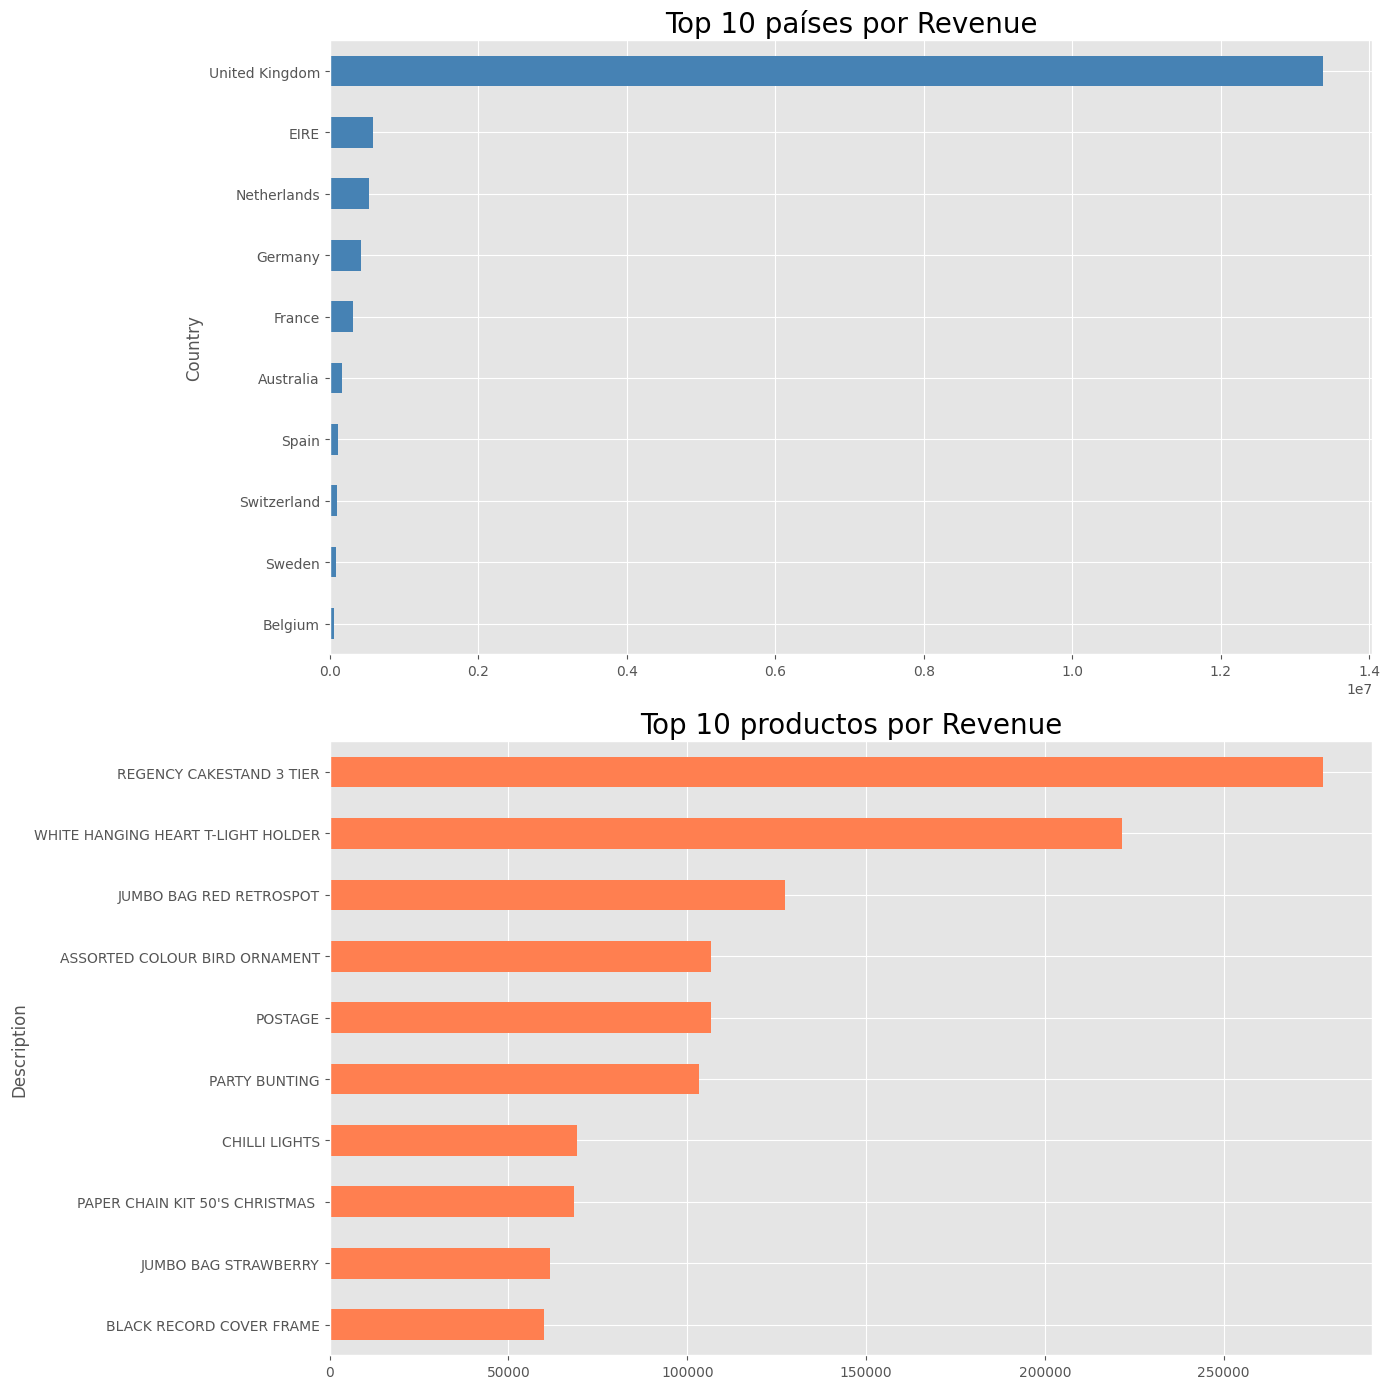

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Top 10 países por Revenue
top_countries = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_countries.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 países por Revenue', fontsize = 20)
axes[0].invert_yaxis()

# Top 10 productos por Revenue
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 productos por Revenue', fontsize = 20)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Agrupación por cliente y *'cutoff_date'*

Hasta aquí teníamos **transacciones** (una fila por línea de factura). El modelo necesita **una fila por cliente**.
### Lógica de la fecha de corte

Definimos `CUTOFF = 2011-10-01`. Esta fecha divide el dataset en dos zonas:

| Zona | Período | Uso |
|---|---|---|
| Antes del corte | dic 2009 - sep 2011 | Construir **features** por cliente |
| Después del corte | oct 2011 - dic 2011 | Construir la **etiqueta** (recompró = 1 / no recompró = 0) |

Esta separación temporal es lo que **previene el data leakage**: el modelo nunca ve información del futuro durante el entrenamiento.

### Features construidas

| Feature | Descripción |
|---|---|
| `recencia` | Días desde la última compra hasta el corte |
| `frecuencia` | Número de facturas distintas | 
| `revenue_total` | Gasto total acumulado | 
| `ticket_medio` | Revenue medio por factura |
| `n_productos` | Productos únicos comprados |
| `n_paises` | Países desde los que ha comprado |
| `pais` | País más frecuente del cliente |

In [12]:
CUTOFF = pd.Timestamp('2011-10-01')

df_before = df[df['InvoiceDate'] < CUTOFF].copy()   # Features
df_after  = df[df['InvoiceDate'] >= CUTOFF].copy()  # Etiqueta

print(f'Filas antes del CUTOFF:   {len(df_before):,} | Clientes: {df_before["Customer ID"].nunique():,}')
print(f'Filas después del CUTOFF: {len(df_after):,}  | Clientes: {df_after["Customer ID"].nunique():,}')

Filas antes del CUTOFF:   649,107 | Clientes: 5,402
Filas después del CUTOFF: 128,805  | Clientes: 2,551


In [13]:
# ── Ticket medio: revenue medio por factura (no por línea) ────────────────────
# Primero sumo el revenue de cada factura completa, luego el promedio por cliente
ticket_por_factura = (
    df_before.groupby(['Customer ID', 'Invoice'])['Revenue']
    .sum()
    .reset_index()
    .groupby('Customer ID')['Revenue']
    .mean()
    .rename('ticket_medio')
)

# ── Agregación principal: una fila por cliente ────────────────────────────────
features = df_before.groupby('Customer ID').agg(
    recencia      = ('InvoiceDate', lambda x: (CUTOFF - x.max()).days),  # días desde última compra
    frecuencia    = ('Invoice',     'nunique'),                           # nº facturas distintas
    revenue_total = ('Revenue',     'sum'),                               # gasto total
    n_productos   = ('StockCode',   'nunique'),                           # productos únicos
    n_paises      = ('Country',     'nunique'),                           # países distintos
    pais          = ('Country',     lambda x: x.mode()[0]),               # país más frecuente
).reset_index()

# Añadimos el ticket medio calculado correctamente
features = features.merge(ticket_por_factura, on='Customer ID')

print(f'Dataset por cliente: {features.shape[0]:,} filas x {features.shape[1]} columnas')
features.head()

Dataset por cliente: 5,402 filas x 8 columnas


,Customer ID,recencia,frecuencia,revenue_total,n_productos,n_paises,pais,ticket_medio
0,12346.00,459,11,372.86,26,1,United Kingdom,33.90
1,12347.00,59,6,3402.39,107,1,Iceland,567.06
2,12348.00,5,5,2019.40,25,1,Finland,403.88
3,12349.00,337,2,2221.14,89,1,Italy,1110.57
4,12350.00,240,1,334.40,17,1,Norway,334.40


In [14]:
# ── Construcción de la etiqueta ───────────────────────────────────────────────
# Un cliente tiene label=1 si aparece en los datos DESPUÉS del corte
# Un cliente tiene label=0 si NO volvió a comprar en el período oct-dic 2011
compraron_despues = set(df_after['Customer ID'].unique())
features['label'] = features['Customer ID'].isin(compraron_despues).astype(int)

print('=== Distribución de la etiqueta ===')
counts = features['label'].value_counts()
print(f'  No recompró (0): {counts[0]:,} clientes ({counts[0]/len(features)*100:.1f}%)')
print(f'  Recompró    (1): {counts[1]:,} clientes ({counts[1]/len(features)*100:.1f}%)')
print(f'\nNulos en el dataset: {features.isnull().sum().sum()}')

=== Distribución de la etiqueta ===
  No recompró (0): 3,289 clientes (60.9%)
  Recompró    (1): 2,113 clientes (39.1%)

Nulos en el dataset: 0


Un **39% de recompra** es una distribución razonablemente equilibrada para clasificación binaria.
No hay desbalance severo.

El AUC será la métrica principal porque es robusta ante cierto desbalance.

## 5. Modelos

**Train/Split**

Divido el dataset de clientes en **80% train** y **20% test**.

- El split se hace **una sola vez**, aquí, antes de tocar ningún modelo
- El conjunto **test no se vuelve a usar** hasta la evaluación final
- Uso `stratify=label` para garantizar que la proporción de recompra (39%) se mantiene igual en train y en test
- Fijo `random_state=42` para que los resultados sean reproducibles

In [16]:
from sklearn.model_selection import train_test_split

# Separamos features (X) de etiqueta (y)
# Eliminamos Customer ID: es un identificador, no una feature predictiva
X = features.drop(columns=['Customer ID', 'label'])
y = features['label']

# Split 80/20 estratificado por la etiqueta
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # mantiene la proporción 39/61 en ambos conjuntos
)

print('=== Tamaños del split ===')
print(f'  Train: {len(X_train):,} clientes ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test:  {len(X_test):,} clientes ({len(X_test)/len(X)*100:.0f}%)')
print()
print('=== Proporción de recompra (label=1) ===')
print(f'  Total: {y.mean()*100:.1f}%')
print(f'  Train: {y_train.mean()*100:.1f}%')
print(f'  Test:  {y_test.mean()*100:.1f}%')

=== Tamaños del split ===
  Train: 4,321 clientes (80%)
  Test:  1,081 clientes (20%)

=== Proporción de recompra (label=1) ===
  Total: 39.1%
  Train: 39.1%
  Test:  39.1%


### 5.1 Regresión logística sin parámetros (baseline)

El Baseline es el modelo más simple posible. Su objetivo no es ser bueno,
sino establecer un **punto de referencia mínimo**: cualquier modelo posterior
debe superarlo para justificar su complejidad adicional.

**Condiciones del Baseline:**
- `LogisticRegression()` sin ningún parámetro (usa los valores por defecto de scikit-learn)
- No añado `StandardScaler` ni `RobustScaler`
- Encoding mínimo de `pais` con `LabelEncoder` (convierte texto a entero, nada más)
- Métrica: **AUC-ROC** (área bajo la curva ROC)

**¿Por qué AUC y no accuracy?**  
La accuracy mide cuántos casos clasificamos bien con un umbral fijo (0.5).  
El AUC mide la capacidad del modelo de **ordenar** correctamente los clientes
de mayor a menor probabilidad de recompra — que es exactamente lo que necesita
el equipo de negocio para priorizar acciones comerciales.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

# Encoding mínimo de pais para el baseline (solo convierte texto a entero)
# No uso OneHotEncoding aquí, lo uso en el Pipeline
le = LabelEncoder()
X_train_bl = X_train.copy()
X_test_bl  = X_test.copy()
X_train_bl['pais'] = le.fit_transform(X_train['pais'])

# Gestionamos países en test que no aparecieron en train
X_test_bl['pais'] = X_test['pais'].map(
    lambda x: x if x in le.classes_ else le.classes_[0]
)
X_test_bl['pais'] = le.transform(X_test_bl['pais'])

# Baseline: LogisticRegression con todos los parámetros por defecto
baseline = LogisticRegression(max_iter=150,random_state=42)
baseline.fit(X_train_bl, y_train)

# Evaluamos con probabilidades (predict_proba), no con clases (predict)
# [:, 1] selecciona la probabilidad de la clase positiva (recompra = 1)
auc_train_bl = roc_auc_score(y_train, baseline.predict_proba(X_train_bl)[:, 1])
auc_val_bl   = roc_auc_score(y_test,  baseline.predict_proba(X_test_bl)[:, 1])

print('=== BASELINE — Logistic Regression (sin preprocesamiento) ===')
print(f'  AUC Train: {auc_train_bl:.4f}')
print(f'  AUC Val:   {auc_val_bl:.4f}')
print(f'  Diferencia: {auc_train_bl - auc_val_bl:.4f}')

=== BASELINE — Logistic Regression (sin preprocesamiento) ===
  AUC Train: 0.7906
  AUC Val:   0.7867
  Diferencia: 0.0039


d:\Data Science Projects\machinelearningproejct\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 150 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=150).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**AUC Train ≈ 0.79 | AUC Val ≈ 0.79**

Un AUC de ~0.79 sin ningún preprocesamiento es un resultado muy sólido para un Baseline.
Significa que el modelo, incluso en su versión más simple, es capaz de separar bien
los clientes que van a recomprar de los que no.

La diferencia train - validation es mínima (~0.004), lo que indica **ausencia de overfitting**.

El modelo ha dado un 'ConvergenceWarning' al establecer las iteraciones máximas en 100, por ello, he aumentado el número de iteraciones a 1000, para obtener el AUC real de la regresión logística sin parámetros.

**Referencia que deben superar los modelos siguientes:** AUC Val > 0.786

### 5.2 Regresión logística con GridSearchCV
#### Preprocesamiento (Pipeline)



Voy a usar dos herramientas clave de scikit-learn:

**`ColumnTransformer`**: aplica transformaciones distintas según el tipo de columna.
- `StandardScaler` y `RobustScaler` sobre las numéricas: escala usando la mediana y el IQR.
El GridSearch va a decidir el mejor Scaler.
- `OneHotEncoder` sobre `pais`: convierte cada país en una columna binaria (0/1).
  `handle_unknown='ignore'` gestiona países en test que no aparecieron en train.

**`Pipeline`**: encadena preprocesamiento + modelo en un solo objeto.
La ventaja crítica es que el `fit` del scaler ocurre **solo sobre train**,
y el `transform` aplica esas mismas escalas a test. Imposible hacer data leakage accidentalmente.

**`GridSearchCV` con cv=5**: prueba todas las combinaciones del diccionario de hiperparámetros
usando validación cruzada de 5 folds sobre train. Devuelve la mejor combinación
según AUC promedio en los 5 folds. El test **no se toca** en ningún momento de este proceso.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Columnas numéricas y categóricas
num_cols = ['recencia', 'frecuencia', 'revenue_total', 'n_productos', 'n_paises', 'ticket_medio']
cat_cols = ['pais']

# ColumnTransformer: distintas transformaciones según tipo de columna
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

print('Preprocesador definido:')
print('  Numericas  →', num_cols)
print('  Categoricas →', cat_cols)

Preprocesador definido:
  Numericas  → ['recencia', 'frecuencia', 'revenue_total', 'n_productos', 'n_paises', 'ticket_medio']
  Categoricas → ['pais']


**Hiperparámetros explorados:**

- `pre__num`: probamos `StandardScaler` y `RobustScaler` dentro del propio grid — GridSearch elige empíricamente el mejor
- `clf__C`: controla la regularización. `C` pequeño = modelo más simple (más regularización); `C` grande = modelo más flexible (menos regularización)
- `clf__tol`: tolerancia de convergencia. Define cuán pequeño debe ser el cambio entre iteraciones para que el optimizador considere que ha convergido. Valores más grandes convergen antes pero con menos precisión

En el Pipeline, los parámetros del preprocesador se referencian como `pre__num` y los del modelo como `clf__C` (nombre del paso + `__` + nombre del parámetro).

In [19]:
# Pipeline con scaler como hiperparámetro: GridSearch elige entre StandardScaler y RobustScaler
pipe_lr = Pipeline([
    ('pre', ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_lr = {
    'pre__num':  [StandardScaler(), RobustScaler()],
    'clf__C':    [0.01, 0.1, 1, 5, 10],
    'clf__tol':  [1e-4, 1e-3, 1e-2],           
}

gs_lr = GridSearchCV(pipe_lr, param_lr, cv=5, scoring='roc_auc', n_jobs=-1)
gs_lr.fit(X_train, y_train)

print(f'Scaler elegido: {type(gs_lr.best_params_["pre__num"]).__name__}')
print(f'Mejor C:        {gs_lr.best_params_["clf__C"]}')
print(f'Mejor tol:      {gs_lr.best_params_["clf__tol"]}')
print(f'CV AUC:         {gs_lr.best_score_:.4f}')

Scaler elegido: RobustScaler
Mejor C:        10
Mejor tol:      0.0001
CV AUC:         0.7923


### 5.3 Decision Tree Classifier con GridSearchCV

**Hiperparámetros explorados:**

- `pre__num`: mismo grid de scalers — aunque los árboles no son sensibles a la escala, lo incluimos para coherencia metodológica
- `clf__criterion`: criterio de pureza para decidir las divisiones del árbol
  - `gini`: mide la probabilidad de clasificar incorrectamente una muestra aleatoria. Más rápido de calcular
  - `entropy`: mide la ganancia de información (basado en teoría de la información). Más costoso pero a veces genera árboles más equilibrados
- `clf__max_depth`: profundidad máxima del árbol. Limita el overfitting
- `clf__min_samples_leaf`: mínimo de clientes en una hoja terminal

In [25]:
pipe_dt = Pipeline([
    ('pre', ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])),
    ('clf', DecisionTreeClassifier(random_state=42))
])

param_dt = {
    'pre__num':              [StandardScaler(), RobustScaler()],
    'clf__criterion':        ['gini', 'entropy'],  # criterio de pureza
    'clf__max_depth':        [3, 5, 7, 10],
    'clf__min_samples_leaf': [10, 20, 50],
}

gs_dt = GridSearchCV(pipe_dt, param_dt, cv=5, scoring='roc_auc', n_jobs=-1)
gs_dt.fit(X_train, y_train)

print(f'Scaler elegido:          {type(gs_dt.best_params_["pre__num"]).__name__}')
print(f'Criterio de pureza:      {gs_dt.best_params_["clf__criterion"]}')
print(f'Profundidad máxima:      {gs_dt.best_params_["clf__max_depth"]}')
print(f'Min samples leaf:        {gs_dt.best_params_["clf__min_samples_leaf"]}')
print(f'CV AUC:                  {gs_dt.best_score_:.4f}')

Scaler elegido:          StandardScaler
Criterio de pureza:      gini
Profundidad máxima:      3
Min samples leaf:        10
CV AUC:                  0.7819


### 5.4 Random Forest Classifier con GridSearchCV

Random Forest entrena múltiples árboles de decisión sobre subconjuntos aleatorios del dataset
y promedia sus predicciones. Al combinar muchos árboles, reduce el overfitting que tiene
un árbol solo.

**Hiperparámetros explorados:**
- `pre__num`: mismo grid de scalers (Random Forest tampoco es sensible a la escala, pero lo incluimos por coherencia)
- `clf__n_estimators`: número de árboles. Más árboles = resultado más estable, pero más tiempo de entrenamiento
- `clf__max_depth`: profundidad de cada árbol individual. `None` = sin límite (el promedio ya controla el overfitting)
- `clf__min_samples_leaf`: mínimo de clientes por hoja en cada árbol

In [26]:
pipe_rf = Pipeline([
    ('pre', ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_rf = {
    'pre__num':              [StandardScaler(), RobustScaler()],
    'clf__n_estimators':     [100, 200],
    'clf__max_depth':        [5, 10, None],
    'clf__min_samples_leaf': [10, 20],
}

gs_rf = GridSearchCV(pipe_rf, param_rf, cv=5, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train, y_train)

print(f'Scaler elegido:     {type(gs_rf.best_params_["pre__num"]).__name__}')
print(f'n_estimators:       {gs_rf.best_params_["clf__n_estimators"]}')
print(f'max_depth:          {gs_rf.best_params_["clf__max_depth"]}')
print(f'min_samples_leaf:   {gs_rf.best_params_["clf__min_samples_leaf"]}')
print(f'CV AUC:             {gs_rf.best_score_:.4f}')

Scaler elegido:     RobustScaler
n_estimators:       200
max_depth:          None
min_samples_leaf:   10
CV AUC:             0.7896


### 5.5 XGBoost con GridSearchCV
XGBoost (Extreme Gradient Boosting) es un modelo de boosting: construye árboles de forma
secuencial, donde cada árbol nuevo corrige los errores del anterior. A diferencia de
Random Forest (árboles en paralelo e independientes), XGBoost aprende de sus propios errores iterativamente.

**¿Por qué probarlo?** Es el modelo más usado en competiciones de ML con datos tabulares.
Suele superar a Random Forest con el tuning adecuado.
**Hiperparámetros explorados:**

- `pre__num`: mismo grid de scalers
- `clf__n_estimators`: número de árboles secuenciales
- `clf__max_depth`: profundidad de cada árbol. En boosting se usan árboles más pequeños (3-5)
- `clf__learning_rate`: cuánto corrige cada árbol nuevo los errores anteriores. Valores pequeños = aprendizaje más lento pero más preciso

In [41]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ('pre', ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1))
])

param_xgb = {
    'pre__num':           [StandardScaler(), RobustScaler()],
    'clf__n_estimators':  [100, 200],
    'clf__max_depth':     [3, 5],
    'clf__learning_rate': [0.05, 0.1],
}

gs_xgb = GridSearchCV(pipe_xgb, param_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
gs_xgb.fit(X_train, y_train)

auc_xgb_test = roc_auc_score(y_test, gs_xgb.predict_proba(X_test)[:, 1])

print(f'Scaler elegido:    {type(gs_xgb.best_params_["pre__num"]).__name__}')
print(f'n_estimators:      {gs_xgb.best_params_["clf__n_estimators"]}')
print(f'max_depth:         {gs_xgb.best_params_["clf__max_depth"]}')
print(f'learning_rate:     {gs_xgb.best_params_["clf__learning_rate"]}')
print(f'CV AUC:            {gs_xgb.best_score_:.4f}')

Scaler elegido:    StandardScaler
n_estimators:      100
max_depth:         3
learning_rate:     0.05
CV AUC:            0.7938


**Este modelo da una solución algo mejor que la regresión logística, por ello es el mejor modelo que he encontrado**

### 5.6 Resumen comparativo de todos los modelos
Comparamos el CV AUC (rendimiento estimado sobre train con validación cruzada) de los cuatro modelos frente al Baseline.
El mejor modelo de esta tabla será el que evaluemos sobre test en la siguiente sección.

In [47]:
resultados = pd.DataFrame([
    {'Modelo': 'Baseline (LR sin preprocesar)', 
     'CV AUC': round(auc_val_bl, 4),
     'Scaler': '-',
     'Mejor parámetro': 'max_iter=1000'},
    {'Modelo': 'Logistic Regression', 
     'CV AUC': round(gs_lr.best_score_, 4),
     'Scaler': type(gs_lr.best_params_['pre__num']).__name__,
     'Mejor parámetro': f'C={gs_lr.best_params_["clf__C"]}, tol={gs_lr.best_params_["clf__tol"]}'},
    {'Modelo': 'Decision Tree', 
     'CV AUC': round(gs_dt.best_score_, 4),
     'Scaler': type(gs_dt.best_params_['pre__num']).__name__,
     'Mejor parámetro': f'criterion={gs_dt.best_params_["clf__criterion"]}, depth={gs_dt.best_params_["clf__max_depth"]}'},
    {'Modelo': 'Random Forest', 
     'CV AUC': round(gs_rf.best_score_, 4),
     'Scaler': type(gs_rf.best_params_['pre__num']).__name__,
     'Mejor parámetro': f'n_est={gs_rf.best_params_["clf__n_estimators"]}, depth={gs_rf.best_params_["clf__max_depth"]}'},
    {'Modelo': 'XGBoost', 
     'CV AUC': round(gs_xgb.best_score_, 4),
     'Scaler': type(gs_xgb.best_params_['pre__num']).__name__,
     'Mejor parámetro': f'n_est={gs_xgb.best_params_["clf__n_estimators"]}, depth={gs_xgb.best_params_["clf__max_depth"]}, lr={gs_xgb.best_params_["clf__learning_rate"]}'}

]).sort_values('CV AUC', ascending=False).reset_index(drop=True)

print(resultados.to_string(index=False, float_format='{:.4f}'.format))
print(f'\nMejor modelo: {resultados.iloc[0]["Modelo"]}')

                       Modelo  CV AUC         Scaler             Mejor parámetro
                      XGBoost  0.7938 StandardScaler n_est=100, depth=3, lr=0.05
          Logistic Regression  0.7923   RobustScaler            C=10, tol=0.0001
                Random Forest  0.7896   RobustScaler       n_est=200, depth=None
Baseline (LR sin preprocesar)  0.7868              -               max_iter=1000
                Decision Tree  0.7819 StandardScaler     criterion=gini, depth=3

Mejor modelo: XGBoost


## 6. Evaluación final sobre test

El mejor modelo según CV AUC es el **modelo XGBoost**.

Ahora seguimos el protocolo correcto:
1. Reentrenamos ese modelo con **todo el conjunto train (80%)** — incluyendo los datos
   que hasta ahora usaba la validación cruzada
2. Evaluamos **una única vez** sobre el conjunto test (20%)

> El test no se ha tocado en ningún momento anterior. Este es su único uso.
> Cualquier decisión tomada a partir de este resultado introduciría data leakage.

In [46]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay

# 1. ¡Extraemos directamente el Pipeline ganador ya entrenado!
# Ya contiene el StandardScaler y el XGBoost con los mejores parámetros
best_model = gs_xgb.best_estimator_

# 2. Predicciones sobre test
y_prob = best_model.predict_proba(X_test)[:, 1]  
y_pred = best_model.predict(X_test)              

# 3. AUC - métrica principal
auc_test = roc_auc_score(y_test, y_prob)
print(f'AUC Test (evaluación final): {auc_test:.4f}')

# 4. Comparamos con su propio CV
print(f'AUC CV   (estimación train): {gs_xgb.best_score_:.4f}')
print(f'Diferencia:                  {gs_xgb.best_score_ - auc_test:.4f}')

AUC Test (evaluación final): 0.7926
AUC CV   (estimación train): 0.7938
Diferencia:                  0.0013


### Matriz de confusión

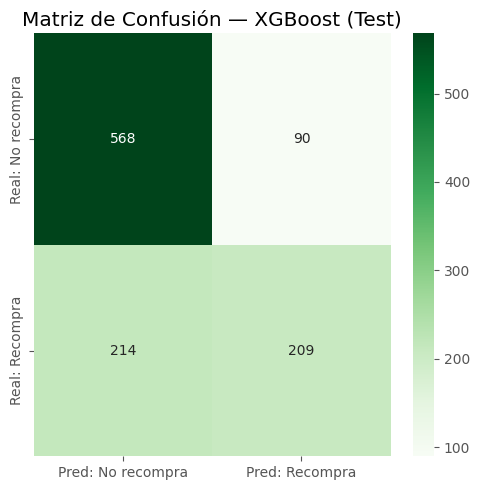


Verdaderos Negativos  (TN): 568  — no recompran y el modelo lo predice bien
Falsos Positivos      (FP): 90  — no recompran pero el modelo dice que sí
Falsos Negativos      (FN): 214  — recompran pero el modelo no los detecta
Verdaderos Positivos  (TP): 209  — recompran y el modelo lo predice bien


In [50]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',  # Cambiado a 'Greens' para que haga juego con la curva ROC
            xticklabels=['Pred: No recompra', 'Pred: Recompra'],
            yticklabels=['Real: No recompra', 'Real: Recompra'],
            ax=ax)

ax.set_title('Matriz de Confusión — XGBoost (Test)') 
plt.tight_layout()
plt.show()

print(f'\nVerdaderos Negativos  (TN): {tn}  — no recompran y el modelo lo predice bien')
print(f'Falsos Positivos      (FP): {fp}  — no recompran pero el modelo dice que sí')
print(f'Falsos Negativos      (FN): {fn}  — recompran pero el modelo no los detecta')
print(f'Verdaderos Positivos  (TP): {tp}  — recompran y el modelo lo predice bien')

### Curva ROC (con xgboost)

AUC Test: 0.7926
AUC CV:   0.7938


d:\Data Science Projects\machinelearningproejct\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


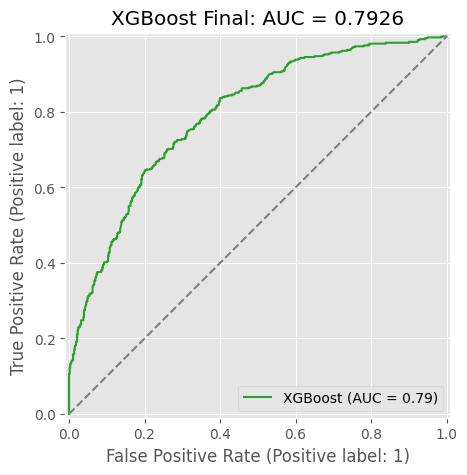

In [49]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

best_model = gs_xgb.best_estimator_
y_prob = best_model.predict_proba(X_test)[:, 1]  
auc_test = roc_auc_score(y_test, y_prob)
print(f'AUC Test: {auc_test:.4f}')
print(f'AUC CV:   {gs_xgb.best_score_:.4f}')
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, name='XGBoost', color='#2ca02c', ax=ax)
ax.plot([0, 1], [0, 1], color='#7f7f7f', linestyle='--')
ax.set_title(f'XGBoost Final: AUC = {auc_test:.4f}')
plt.show()

### Ajuste del umbral de decisión

Por defecto, los modelos clasifican como recompra cuando `P(recompra) >= 0.5`.
Pero este umbral no siempre es el óptimo para el negocio.

**Trade-off clave:**

- **Umbral más alto (0.6, 0.7):** el modelo solo dice "recompra" cuando está muy seguro
  → menos falsos positivos (no malgastamos campaña en quien no va a comprar)
  → más falsos negativos (perdemos clientes que sí habrían comprado)
- **Umbral más bajo (0.3, 0.4):** el modelo es más agresivo identificando recompras
  → más falsos positivos (enviamos campaña a más clientes innecesariamente)
  → menos falsos negativos (capturamos más clientes que sí comprarían)

La elección depende de cuánto cuesta cada tipo de error para el negocio.

In [39]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# Usamos el mejor modelo (Logistic Regression) ya entrenado
y_prob_final = best_model.predict_proba(X_test)[:, 1]

umbrales = [0.5, 0.6, 0.7]
filas = []

for t in umbrales:
    y_pred_t = (y_prob_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    filas.append({
        'Umbral':    t,
        'TP':        tp,
        'FP':        fp,
        'FN':        fn,
        'TN':        tn,
        'Precision': round(tp / (tp + fp) if (tp + fp) > 0 else 0, 3),
        'Recall':    round(tp / (tp + fn) if (tp + fn) > 0 else 0, 3),
        'Accuracy':  round((tp + tn) / len(y_test), 3),
    })

df_umbrales = pd.DataFrame(filas)
print(df_umbrales.to_string(index=False))

 Umbral  TP  FP  FN  TN  Precision  Recall  Accuracy
   0.50 230 110 193 548       0.68    0.54      0.72
   0.60 162  55 261 603       0.75    0.38      0.71
   0.70 103  27 320 631       0.79    0.24      0.68


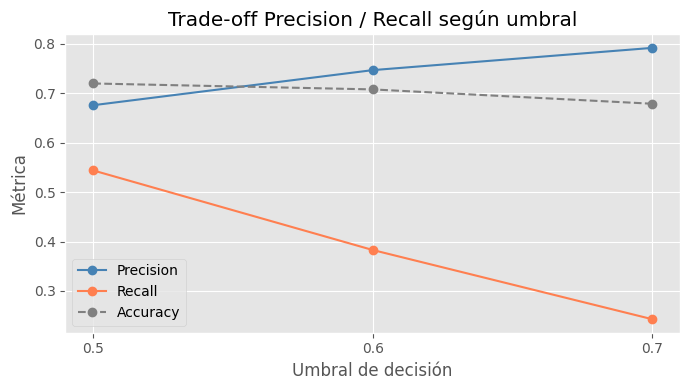

Interpretación:
  Umbral 0.5 → equilibrio entre precision y recall (uso general)
  Umbral 0.6 → más precision: identificamos recompras con mayor certeza
  Umbral 0.7 → máxima precision: muy selectivos, capturamos menos pero más seguros


In [40]:
# Visualización del trade-off precision/recall según umbral
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_umbrales['Umbral'], df_umbrales['Precision'], marker='o', label='Precision', color='steelblue')
ax.plot(df_umbrales['Umbral'], df_umbrales['Recall'],    marker='o', label='Recall',    color='coral')
ax.plot(df_umbrales['Umbral'], df_umbrales['Accuracy'],  marker='o', label='Accuracy',  color='gray', linestyle='--')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Métrica')
ax.set_title('Trade-off Precision / Recall según umbral')
ax.legend()
ax.set_xticks(umbrales)
plt.tight_layout()
plt.show()

print('Interpretación:')
print('  Umbral 0.5 → equilibrio entre precision y recall (uso general)')
print('  Umbral 0.6 → más precision: identificamos recompras con mayor certeza')
print('  Umbral 0.7 → máxima precision: muy selectivos, capturamos menos pero más seguros')

## 7. Explicabilidad

En regresión logística, la importancia de cada variable se mide por el **valor absoluto
de su coeficiente** tras el escalado. Un coeficiente alto positivo indica que aumentar
esa variable aumenta la probabilidad de recompra. Un coeficiente negativo indica lo contrario.

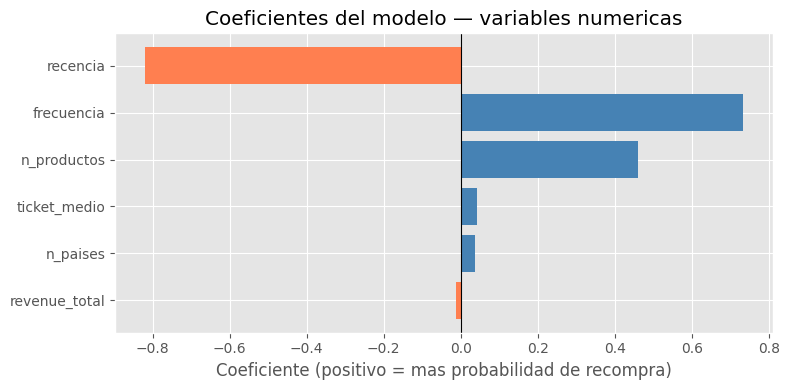

      feature  coef
     recencia -0.82
   frecuencia  0.73
  n_productos  0.46
 ticket_medio  0.04
     n_paises  0.04
revenue_total -0.01


In [35]:
# Extraemos nombres de features tras el OneHotEncoding
feature_names_num = num_cols
feature_names_cat = (
    best_model.named_steps['pre']
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_features = feature_names_num + feature_names_cat
coefs = best_model.named_steps['clf'].coef_[0]

importance_df = pd.DataFrame({'feature': all_features, 'coef': coefs})
importance_df['abs_coef'] = importance_df['coef'].abs()
importance_df = importance_df.sort_values('abs_coef', ascending=False)

# Visualizamos solo las variables numéricas (las más interpretables para negocio)
importance_num = importance_df[importance_df['feature'].isin(num_cols)].copy()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if c > 0 else 'coral' for c in importance_num['coef']]
ax.barh(importance_num['feature'], importance_num['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes del modelo — variables numericas')
ax.set_xlabel('Coeficiente (positivo = mas probabilidad de recompra)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_num[['feature', 'coef']].to_string(index=False))

**Visualización del árbol de decisión**

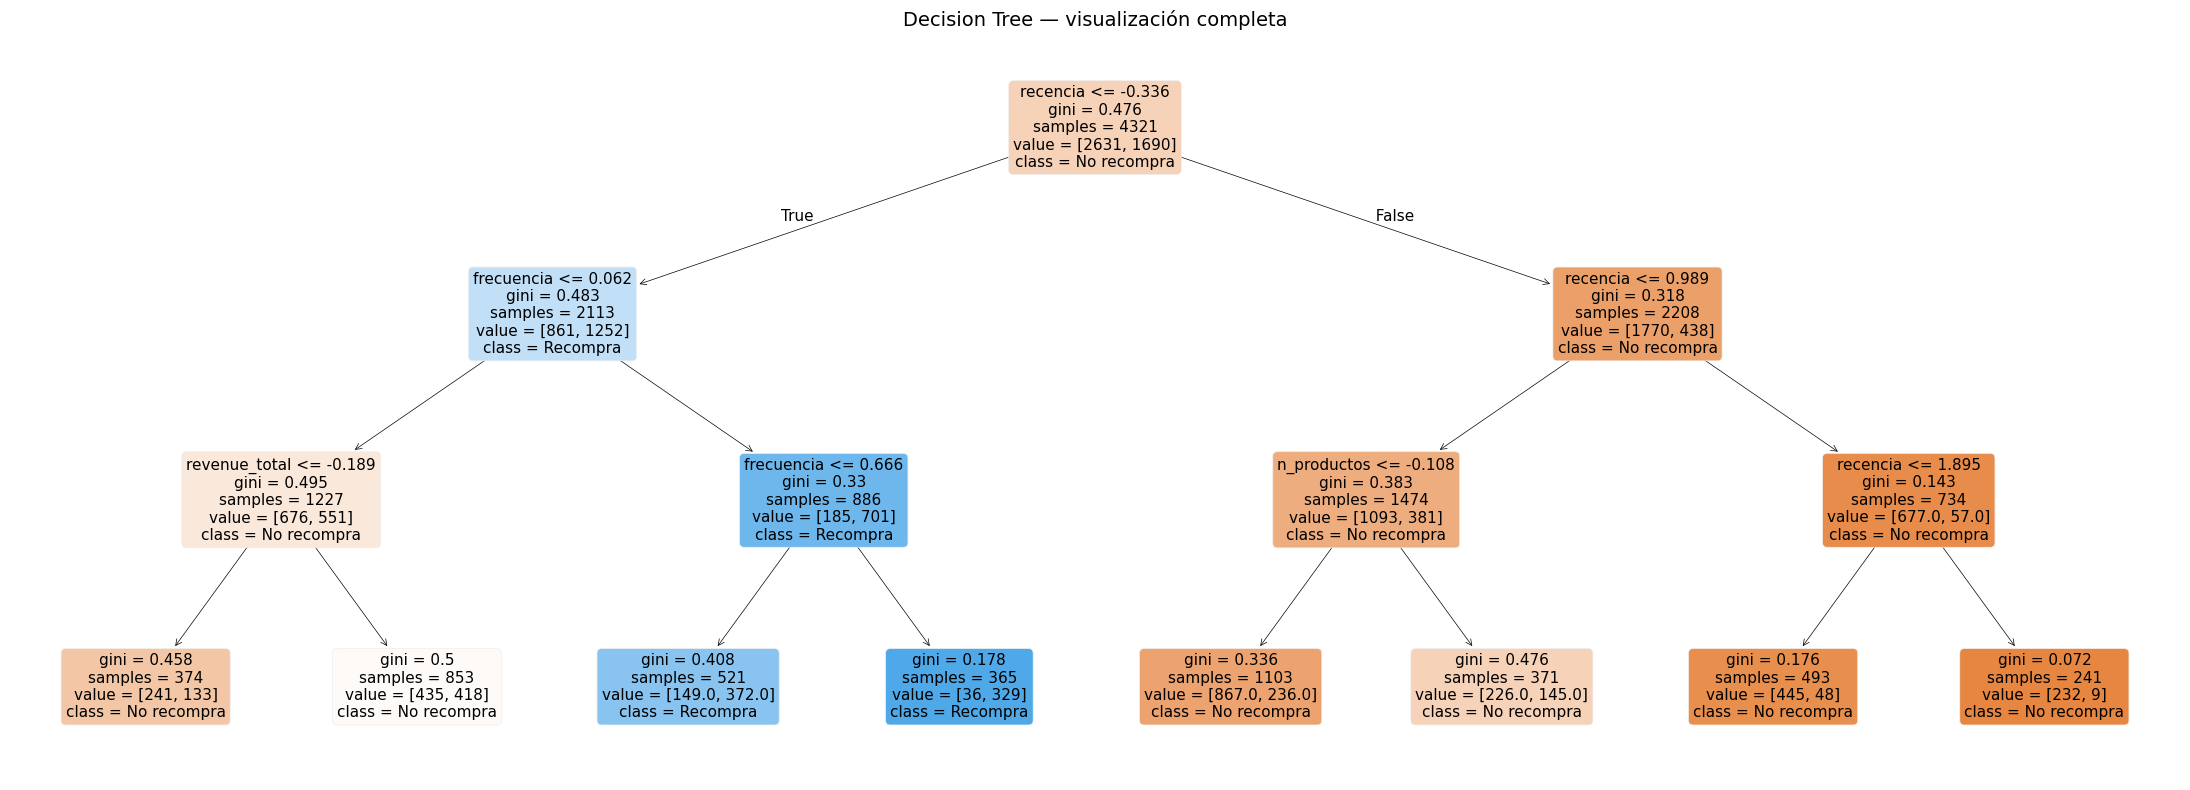

In [37]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extraemos el árbol del mejor Pipeline
dt_model = gs_dt.best_estimator_.named_steps['clf']

# Reconstruimos los nombres de features tras el encoding
feature_names_cat = (
    gs_dt.best_estimator_.named_steps['pre']
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_features = num_cols + feature_names_cat

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names=all_features,
    class_names=['No recompra', 'Recompra'],
    filled=True,       # colorea según clase dominante: naranja = no recompra, azul = recompra
    rounded=True,      # bordes redondeados
    fontsize=11,
    ax=ax
)
plt.title('Decision Tree — visualización completa', fontsize=14)
plt.tight_layout()
plt.show()

Debido a la propia metodología del proceso, la raiz del arbol es aquella que considera que tiene más pureza en la primera división, y por tanto se trata de la variable más importante para poder clasificar la intención de recompra.

### Interpretación de los coeficientes

| Feature | Coeficiente | Interpretación de negocio |
|---|---|---|
| `recencia` | negativo | Cuanto más reciente la última compra, más probable la recompra |
| `frecuencia` | positivo | Clientes que compran más a menudo tienen más probabilidad de volver |
| `revenue_total` | positivo | Clientes de mayor valor histórico tienden a ser más fieles |
| `ticket_medio` | variable | Ticket medio alto puede indicar mayorista con comportamiento distinto |
| `n_productos` | positivo | Mayor variedad de productos comprados → mayor engagement con el catálogo |

> **Nota sobre `pais`:** los coeficientes de los países dominan el top 10 en valor absoluto,
pero son difíciles de interpretar para negocio ya que dependen del volumen de clientes
por país.

## 8. Conclusiones y propuesta de uso

### Decisiones metodológicas clave

- **Fecha de corte (1 oct 2011):** separa features y etiqueta para evitar data leakage
- **Scaler elegido por GridSearch:** cada modelo eligió  entre RobustScaler y StandardScaler
- **Criterion Gini** en Decision Tree: confirmado por GridSearch como mejor criterio de pureza
- **Umbral 0.5** como referencia; ajustable a 0.6-0.7 si el negocio prioriza precisión sobre cobertura

### Propuesta de uso para el equipo de negocio

El modelo genera una **probabilidad de recompra** para cada cliente:

- **P > 0.7** → **Fidelización**: descuentos exclusivos, acceso anticipado a nuevos productos
- **P entre 0.4 y 0.7** → **Nurturing**: newsletter personalizada, recomendaciones por historial
- **P < 0.4** → **Retención**: campaña de reactivación, oferta especial de recuperación

### Próximos pasos

- **Ajustar el umbral** según el coste real de cada tipo de error (FP vs FN) para el negocio
- **Features adicionales:** estacionalidad de compra, días entre compras, categoría de producto preferida
- **Reentrenamiento periódico:** el comportamiento de los clientes cambia; el modelo debe actualizarse con datos recientes
- **Segmentación previa:** construir modelos distintos para mayoristas y minoristas, ya que tienen patrones de compra muy diferentes